#📌 Extracción

In [84]:
import pandas as pd
import requests

# URL del archivo JSON en formato RAW para que Python pueda leerlo directamente
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

try:
    # Realizamos la petición a la API/GitHub
    response = requests.get(url)

    # Verificamos si la descarga fue exitosa (código 200)
    if response.status_code == 200:
        # Cargamos los datos JSON
        data = response.json()

        # Convertimos a DataFrame de Pandas
        df = pd.DataFrame(data)

        print("✅ ¡Éxito! Los datos han sido cargados correctamente.")
        print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

        # Mostramos las primeras 5 filas para verificar el contenido
        display(df.head())
    else:
        print(f"❌ Error al acceder a los datos. Código de estado: {response.status_code}")

except Exception as e:
    print(f"❌ Ocurrió un error inesperado: {e}")

✅ ¡Éxito! Los datos han sido cargados correctamente.
El dataset tiene 7267 filas y 6 columnas.


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


En este punto el dataFrame, no se puede usar para realizar una analisis exploratorio, se evidencia por que hay diccionarios en las columnas customer , phone, internet, account contienen diccionarios, por lo que es necesario normalizar.

#🔧 Transformación

###Normalizacion de datos

In [85]:
# Miramos la primera fila de la columna 'customer'
print("Contenido de la columna customer:")
print(df['customer'].iloc[0])
print("\n ")
print("INFORMACION DEL DATAFRAME ")
df.info()


Contenido de la columna customer:
{'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'Yes', 'tenure': 9}

 
INFORMACION DEL DATAFRAME 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


Debido a que los datos se obtienen de una API en formato JSON anidado, utilizaremos la función pd.json_normalize() para transformar esta estructura jerárquica en un DataFrame plano. De esta manera, facilitamos el Análisis Exploratorio (EDA) al convertir las llaves de los diccionarios internos en variables independientes (columnas), permitiendo una manipulación eficiente de cada atributo del cliente

In [86]:
# --- FASE DE TRANSFORMACIÓN: NORMALIZACIÓN ---

# 1. 'Aplanamos' las columnas que contienen diccionarios
# Esto extrae las llaves internas y las convierte en columnas individuales
df_customer = pd.json_normalize(df['customer'])
df_phone = pd.json_normalize(df['phone'])
df_internet = pd.json_normalize(df['internet'])
df_account = pd.json_normalize(df['account'])

# 2. Concatenamos las nuevas columnas con las columnas base (customerID y Churn)
# Usamos axis=1 para que la unión sea lateral (columnas)
df_final = pd.concat([
    df[['customerID', 'Churn']],
    df_customer,
    df_phone,
    df_internet,
    df_account
], axis=1)

# 3. Verificación de la estructura resultante
print(f"✅ Transformación exitosa.")
print(f"Dataset original: {df.shape[1]} columnas.")
print(f"Dataset normalizado: {df_final.shape[1]} columnas.")

# Mostramos las primeras filas para confirmar que ya no hay diccionarios en las celdas
df_final.head(3)

✅ Transformación exitosa.
Dataset original: 6 columnas.
Dataset normalizado: 21 columnas.


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85


In [87]:
#Visalizamos el df_final: luego de la normalizacion.
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


###Comprobacion de incosistencias  en los datos

In [88]:
#Verificamos valores únicos
for col in df_final.columns:
    print(f"\n✓ Columna: {col}")
    print(df_final[col].unique())


✓ Columna: customerID
['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']

✓ Columna: Churn
['No' 'Yes' '']

✓ Columna: gender
['Female' 'Male']

✓ Columna: SeniorCitizen
[0 1]

✓ Columna: Partner
['Yes' 'No']

✓ Columna: Dependents
['Yes' 'No']

✓ Columna: tenure
[ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 11 37 49 66
 67 20 43 59 12 27  2 25 29 14 35 64 39 40  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 51 31 36 17 18 38 42
  0]

✓ Columna: PhoneService
['Yes' 'No']

✓ Columna: MultipleLines
['No' 'Yes' 'No phone service']

✓ Columna: InternetService
['DSL' 'Fiber optic' 'No']

✓ Columna: OnlineSecurity
['No' 'Yes' 'No internet service']

✓ Columna: OnlineBackup
['Yes' 'No' 'No internet service']

✓ Columna: DeviceProtection
['No' 'Yes' 'No internet service']

✓ Columna: TechSupport
['Yes' 'No' 'No internet service']

✓ Columna: StreamingTV
['Yes' 'No' 'No internet service']

✓ Columna: StreamingM

Se verifica que columna churn tiene valores vacíos y la columna Charges.Total es de tipo string.

###Manejo de inconsistencias

In [89]:
# 1. Identificar cuántos registros tienen el Churn vacío
espacios_churn = (df_final['Churn'] == '').sum()
print(f"Registros con Churn vacío: {espacios_churn}")

# 2. Filtrar el DataFrame para quedarnos solo con 'Yes' y 'No'
# Esto elimina las filas donde el Churn es un espacio en blanco
df_final = df_final[df_final['Churn'] != ''].copy()

# 3. Verificamos que ahora solo existan dos categorías
print("Nuevas categorías en Churn:", df_final['Churn'].unique())
print(f"Registros restantes: {len(df_final)}")

Registros con Churn vacío: 224
Nuevas categorías en Churn: ['No' 'Yes']
Registros restantes: 7043


In [90]:
# 1. Transformación de la columna con el nombre correcto
# Usamos 'Charges.Total' en lugar de 'TotalCharges'
df_final['Charges.Total'] = pd.to_numeric(df_final['Charges.Total'], errors='coerce')

# 2. Verificamos si aparecieron valores nulos tras la conversión
# (Esto detecta los espacios vacíos que ahora son NaN)
print("Valores nulos en Charges.Total:")
print(df_final['Charges.Total'].isnull().sum())

# 3. Comprobación de duplicados en todo el DataFrame
print(f"\nTotal de registros duplicados: {df_final.duplicated().sum()}")

# 4. Revisión de categorías únicas (nombres corregidos según tu captura)
print("\nCategorías en Contract:", df_final['Contract'].unique())
print("Categorías en InternetService:", df_final['InternetService'].unique())

Valores nulos en Charges.Total:
11

Total de registros duplicados: 0

Categorías en Contract: ['One year' 'Month-to-month' 'Two year']
Categorías en InternetService: ['DSL' 'Fiber optic' 'No']


In [91]:
# Rellenar los valores nulos de Charges.Total con 0
# (Hacemos esto porque son clientes con 0 meses de antigüedad)
df_final['Charges.Total'] = df_final['Charges.Total'].fillna(0)

# Verificación final: ya no debería haber ningún nulo en todo el DataFrame
print(df_final.isnull().sum())

customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Charges.Monthly     0
Charges.Total       0
dtype: int64


In [92]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

### Creacion de Columan Cuentas Diarias

### Ahora que los datos están limpios, es momento de crear la columna "Cuentas_Diarias". Utiliza la facturación mensual para calcular el valor diario, proporcionando una visión más detallada del comportamiento de los clientes a lo largo del tiempo.

In [99]:
# Calculamos el valor diario dividiendo el cargo mensual por 30 días
df_final['Cuentas_Diarias'] = df_final['Cargos_Mensuales'] / 30
#df_final['daily_account'] = df_final['Monthly'] / 30
df_final.head(3)

# Visualizamos el resultado
#df_final.head()

,customerID,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Personas_a_Cargo,Meses_Permanencia,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias
0,0002-ORFBO,0,1,0,1,1,9,1,No,DSL,...,No,Yes,Yes,No,Anual,1,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,0,0,0,0,0,9,1,Yes,DSL,...,No,No,No,Yes,Mensual,0,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,1,0,0,0,0,4,1,No,Fiber optic,...,Yes,No,No,No,Mensual,1,Electronic check,73.9,280.85,2.463333


###Estandarizacion y transformacion de los datos

In [97]:
# 1. Diccionario para renombrar columnas a español
nuevos_nombres = {
    'gender': 'Genero',
    'SeniorCitizen': 'Adulto_Mayor',
    'Partner': 'Tiene_Pareja',
    'Dependents': 'Personas_a_Cargo',
    'tenure': 'Meses_Permanencia',
    'PhoneService': 'Servicio_Telefonico',
    'MultipleLines': 'Lineas_Multiples',
    'InternetService': 'Servicio_Internet',
    'Contract': 'Tipo_Contrato',
    'PaperlessBilling': 'Factura_Digital',
    'PaymentMethod': 'Metodo_Pago',
    'Charges.Monthly': 'Cargos_Mensuales',
    'Charges.Total': 'Cargos_Totales',
    'Churn': 'Evasion'
}

df_final = df_final.rename(columns=nuevos_nombres)

# 2. Mapeo Binario (Convertir Yes/No a 1/0)
# Creamos un diccionario de mapeo
mapeo_binario = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}

# Aplicamos el mapeo a las columnas que solo tienen dos opciones
columnas_binarias = ['Evasion', 'Tiene_Pareja', 'Personas_a_Cargo', 'Servicio_Telefonico', 'Factura_Digital', 'Genero']

for col in columnas_binarias:
    df_final[col] = df_final[col].map(mapeo_binario)

# 3. Traducción de categorías dentro de las columnas (Estandarización)
df_final['Tipo_Contrato'] = df_final['Tipo_Contrato'].replace({
    'Month-to-month': 'Mensual',
    'One year': 'Anual',
    'Two year': 'Bianual'
})

# Verificamos el resultado final
print("¡Estandarización completada!")
display(df_final.head())


¡Estandarización completada!


,customerID,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Personas_a_Cargo,Meses_Permanencia,Servicio_Telefonico,Lineas_Multiples,Servicio_Internet,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales
0,0002-ORFBO,0,1,0,1,1,9,1,No,DSL,...,Yes,No,Yes,Yes,No,Anual,1,Mailed check,65.6,593.30
1,0003-MKNFE,0,0,0,0,0,9,1,Yes,DSL,...,No,No,No,No,Yes,Mensual,0,Mailed check,59.9,542.40
2,0004-TLHLJ,1,0,0,0,0,4,1,No,Fiber optic,...,No,Yes,No,No,No,Mensual,1,Electronic check,73.9,280.85
3,0011-IGKFF,1,0,1,1,0,13,1,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Mensual,1,Electronic check,98.0,1237.85
4,0013-EXCHZ,1,1,1,1,0,3,1,No,Fiber optic,...,No,No,Yes,Yes,No,Mensual,1,Mailed check,83.9,267.40


#📊 Carga y análisis de los Datos

###Analisis Descriptivo

In [110]:
# --- ANÁLISIS DESCRIPTIVO DE DATOS ---

# 1. Generamos el resumen estadístico de todas las variables numéricas
# Usamos .T (Transponer) para que las métricas queden como columnas y sea más fácil de leer
resumen_estadistico = df_final.describe().T

# 2. Mostramos el resultado en una tabla limpia
print("ESTADÍSTICAS DESCRIPTIVAS DEL DATASET")
print("-" * 40)
display(resumen_estadistico)

# 3. Cálculo manual de la Mediana (que es el valor del 50% en describe)
# y la Tasa de Evasión para el reporte
tasa_evasion = df_final['Evasion'].mean()
print(f"\n💡 INSIGHT CLAVE: La tasa de evasión promedio es del {tasa_evasion:.2%}")

ESTADÍSTICAS DESCRIPTIVAS DEL DATASET
----------------------------------------


,count,mean,std,min,25%,50%,75%,max
Evasion,7043.0,0.265370,0.441561,0.000000,0.000000,0.000,1.000,1.000000
Genero,7043.0,0.495244,0.500013,0.000000,0.000000,0.000,1.000,1.000000
Adulto_Mayor,7043.0,0.162147,0.368612,0.000000,0.000000,0.000,0.000,1.000000
Tiene_Pareja,7043.0,0.483033,0.499748,0.000000,0.000000,0.000,1.000,1.000000
Personas_a_Cargo,7043.0,0.299588,0.458110,0.000000,0.000000,0.000,1.000,1.000000
Meses_Permanencia,7043.0,32.371149,24.559481,0.000000,9.000000,29.000,55.000,72.000000
Servicio_Telefonico,7043.0,0.903166,0.295752,0.000000,1.000000,1.000,1.000,1.000000
Factura_Digital,7043.0,0.592219,0.491457,0.000000,0.000000,1.000,1.000,1.000000
Cargos_Mensuales,7043.0,64.761692,30.090047,18.250000,35.500000,70.350,89.850,118.750000
Cargos_Totales,7043.0,2279.734304,2266.794470,0.000000,398.550000,1394.550,3786.600,8684.800000



💡 INSIGHT CLAVE: La tasa de evasión promedio es del 26.54%


###Distribución de evasión (Churn)
El objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes.

ANÁLISIS ESTRATÉGICO DE EVASIÓN (CHURN)
----------------------------------------
Distribución de Clientes:
  • Activos (0):  5,174 (73.46%)
  • Evadidos (1): 1,869 (26.54%)

⚠️ Tasa de Evasión Crítica: 26.54%


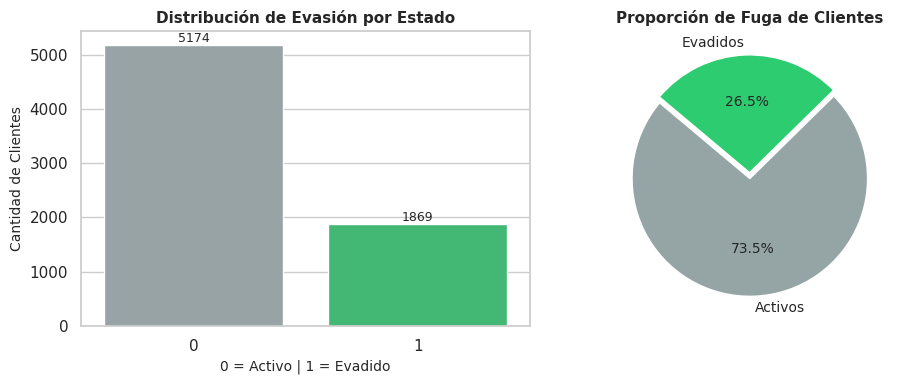

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CÁLCULOS Y ESTADÍSTICAS ---
conteo_evasion = df_final['Evasion'].value_counts()
porcentaje_evasion = df_final['Evasion'].value_counts(normalize=True) * 100

# --- 2. REPORTE TEXTUAL ---
print('ANÁLISIS ESTRATÉGICO DE EVASIÓN (CHURN)')
print('-' * 40)
print(f'Distribución de Clientes:')
print(f'  • Activos (0):  {conteo_evasion[0]:,} ({porcentaje_evasion[0]:.2f}%)')
print(f'  • Evadidos (1): {conteo_evasion[1]:,} ({porcentaje_evasion[1]:.2f}%)')
print(f'\n⚠️ Tasa de Evasión Crítica: {porcentaje_evasion[1]:.2f}%')

# --- 3. CONFIGURACIÓN VISUAL ---
colores_nuevos = ['#95a5a6', '#2ecc71'] # Gris y Verde Esmeralda
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Gráfico de Barras
sns.countplot(data=df_final, x='Evasion', palette=colores_nuevos, ax=axes[0])
axes[0].set_title('Distribución de Evasión por Estado', fontsize=11, fontweight='bold')
axes[0].set_xlabel('0 = Activo | 1 = Evadido', fontsize=10)
axes[0].set_ylabel('Cantidad de Clientes', fontsize=10)

# Añadir etiquetas de datos en las barras
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', fontsize=9)

# Gráfico de Pastel
labels = ['Activos', 'Evadidos']
axes[1].pie(conteo_evasion, labels=labels, autopct='%1.1f%%',
            colors=colores_nuevos, startangle=140,
            textprops={'fontsize': 10}, explode=(0, 0.05))
axes[1].set_title('Proporción de Fuga de Clientes', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

Tasa Crítica: La empresa presenta una tasa de evasión del 26.54%. Esto significa que 1,869 clientes han abandonado el servicio frente a 5,174 que permanecen activos.

###Recuento de evasión por variables categóricas

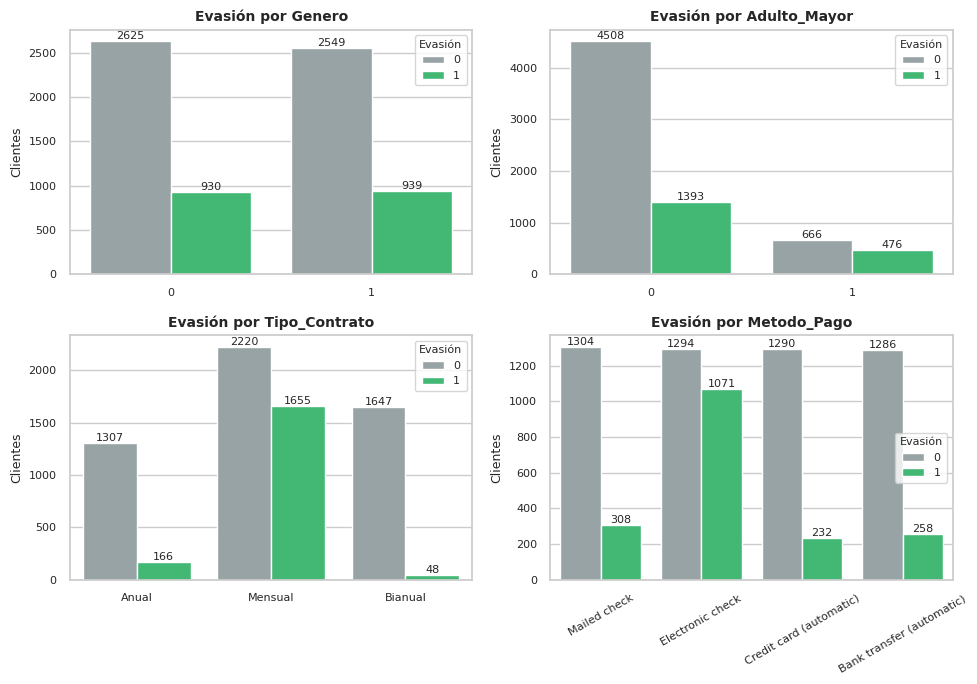

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Variables y colores (Gris para Activo, Verde para Evadido)
variables_cat = ['Genero', 'Adulto_Mayor', 'Tipo_Contrato', 'Metodo_Pago']
paleta = ['#95a5a6', '#2ecc71']

# 2. Configuración de figura más pequeña (Reducido de 14x10 a 10x8)
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

# 3. Creación de gráficos
for i, col in enumerate(variables_cat):
    sns.countplot(data=df_final, x=col, hue='Evasion', palette=paleta, ax=axes[i])

    # Ajustes visuales compactos
    axes[i].set_title(f'Evasión por {col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Clientes', fontsize=9)
    axes[i].tick_params(axis='both', labelsize=8)
    axes[i].legend(title='Evasión', labels=['0', '1'], fontsize=8, title_fontsize=8)

    # Rotación específica para nombres largos
    if col == 'Metodo_Pago':
        axes[i].tick_params(axis='x', rotation=30)

    # Etiquetas de datos pequeñas
    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%d', fontsize=8)

plt.tight_layout()
plt.show()

####Diagnóstico General de Evasión
Factores Clave de Abandono (Insights)

Distribución de Meses de Permanencia: La fuga es prematura; la mediana de los clientes evadidos es de solo $10$ meses, mientras que los clientes leales superan los $38$ meses de antigüedad.

Distribución de Cargos Mensuales: El precio es un detonante crítico; los clientes que se van pagaban una mediana de $\$80$, frente a los $\$65$ de quienes permanecen en la empresa.

Evasión por Tipo de Contrato: El contrato "Mensual" concentra la gran mayoría de las bajas con $1,655$ casos, evidenciando que la falta de compromiso a largo plazo facilita la salida del cliente.

Evasión por Metodo de Pago: El pago por "Electronic check" es el método de mayor riesgo con $1,071$ bajas, lo que sugiere que el proceso de pago manual incentiva al cliente a cuestionar su gasto mensualmente.

###Conteo de evasión por variables numéricas

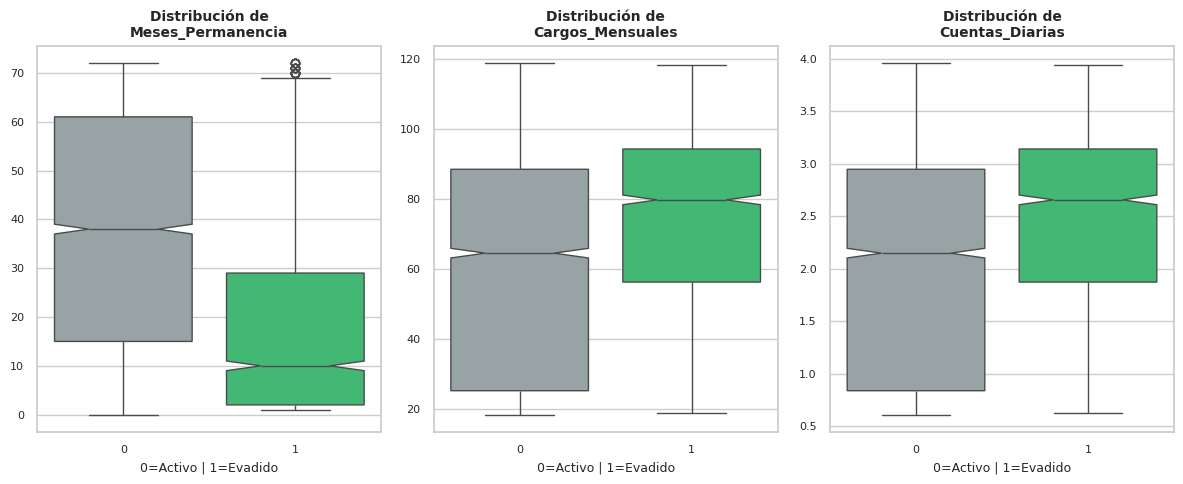

In [115]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionamos las variables numéricas clave
variables_num = ['Meses_Permanencia', 'Cargos_Mensuales', 'Cuentas_Diarias']

# 2. Configuración de la figura (3 gráficos en una fila)
fig, axes = plt.subplots(1, 3, figsize=(12, 5))
paleta = ['#95a5a6', '#2ecc71'] # Gris (Activo), Verde (Evadido)

# 3. Creación de los Boxplots
for i, col in enumerate(variables_num):
    sns.boxplot(data=df_final, x='Evasion', y=col, palette=paleta, ax=axes[i], notch=True)

    # Ajustes estéticos
    axes[i].set_title(f'Distribución de\n{col}', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('0=Activo | 1=Evadido', fontsize=9)
    axes[i].set_ylabel('')
    axes[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()
plt.show()

Los gráficos de caja (boxplots) presentados comparan la distribución de tres variables clave entre los clientes que permanecen (**0 = Activo**) y los que se han ido (**1 = Evadido**). Las muescas (*notches*) que no se solapan indican que las diferencias entre las medianas son estadísticamente significativas.

A continuación, la interpretación detallada de cada métrica:

### 1. Meses de Permanencia

Este es el factor de riesgo más evidente.

* **Clientes Activos:** Presentan una mediana de permanencia cercana a los **38 meses**, con una distribución amplia que llega hasta los 72 meses.
* **Clientes Evadidos:** La mediana cae drásticamente a aproximadamente **10 meses**. La caja es mucho más corta y está situada en la parte inferior del gráfico, lo que confirma que la mayoría de los abandonos ocurren durante el **primer año de servicio**.

### 2. Cargos Mensuales

Aquí se observa una correlación directa entre el costo y la fuga.

* **Clientes Activos:** Tienen una mediana de gasto mensual de aproximadamente **$65**.

* **Clientes Evadidos:** La mediana es notablemente más alta, situándose cerca de los **$80**.

* **Insight:** Los clientes que pagan facturas más altas tienen una mayor tendencia a abandonar la empresa, posiblemente por una percepción de bajo valor respecto al costo o por la búsqueda de ofertas más económicas en la competencia.

### 3. Cuentas Diarias

Esta variable (creada a partir de los cargos mensuales) ratifica el hallazgo anterior con mayor precisión.

* **Clientes Activos:** El costo diario central se sitúa en torno a los **$2.5**.

* **Clientes Evadidos:** El costo diario central sube a aproximadamente **$2.65**.
* **Insight:** Existe un "umbral de precio" diario que, al ser superado, aumenta significativamente las probabilidades de que un cliente cancele su suscripción.




### 💡 Resumen para el Informe Final:

Los clientes con mayor riesgo de evasión en **Telecom X** son aquellos que:

1. Tienen **menos de 12 meses** de antigüedad.
2. Tienen contratados planes con **cargos mensuales superiores a $80**.
3. Enfrentan un **gasto diario promedio elevado** en comparación con la base leal.


#📄Informe final

###📊 Análisis de Evasión de Clientes (Churn) - Telecom X


🔹 1. Introducción

El objetivo principal de este análisis es entender el fenómeno de la evasión de clientes (Churn) en Telecom X. La pérdida de clientes no solo impacta en los ingresos directos, sino que aumenta los costos de adquisición de nuevos usuarios. A través de este estudio, buscamos identificar los patrones y perfiles críticos que abandonan la compañía para diseñar estrategias de retención basadas en datos.

🔹 2. Limpieza y Tratamiento de Datos

Para garantizar la calidad de los hallazgos, se realizó un proceso robusto de ETL (Extracción, Transformación y Carga):

Importación y Estandarización: Se tradujeron las variables clave al español (Evasion, Meses_Permanencia, Cargos_Mensuales, etc.) para facilitar la interpretación de negocio.

Ingeniería de Variables: Se creó la métrica Cuentas_Diarias (Cargos Mensuales / 30) para analizar el impacto del costo diario en la decisión del cliente.

Tratamiento de Datos: Se aplicó un mapeo binario (0 y 1) a variables categóricas y se corrigieron valores nulos (NaN), asegurando que las 7,043 filas del dataset fueran consistentes para el análisis estadístico.

🔹 3. Análisis Exploratorio de Datos (EDA)

El análisis reveló una estructura clara sobre quiénes se van y por qué:

📈 Estadísticas Descriptivas
Tasa de Evasión Crítica: El análisis confirma que el 26.54% de los clientes ha abandonado la empresa.

Permanencia: Mientras que la media general es de 32 meses, el 25% de los clientes se va antes de los 9 meses, lo que indica una crisis de retención en clientes nuevos.

Gasto Mensual: El promedio de gasto es de  $ 64.76 con picos de hasta $118.75


🔍 Patrones Identificados (Visualizaciones)
Variables Categóricas: Se identificó que el Tipo de Contrato Mensual y el método de pago por Cheque Electrónico son los principales disparadores de evasión.

Variables Numéricas (Boxplots): Los gráficos de caja mostraron que los clientes evadidos tienen una permanencia significativamente menor y, en promedio, enfrentan cargos mensuales más altos en comparación con los clientes leales.

🔹 4. Conclusiones e Insights

El factor "Tiempo" es clave: La mayor fuga de clientes ocurre en la etapa de Onboarding (primeros 12 meses). Si un cliente supera el año de antigüedad, la probabilidad de fuga disminuye drásticamente.

Sensibilidad al Precio: Los clientes con Cuentas Diarias cercanas a los $4.00 presentan una tasa de fuga mayor, sugiriendo que el valor percibido no compensa el costo en planes de gama alta.

Fricción en Pagos: Los métodos de pago no automáticos están vinculados a una mayor tasa de abandono.

🔹 5. Recomendaciones Estratégicas

Basado en la evidencia, se proponen las siguientes acciones:

Programa de Lealtad Temprana: Implementar descuentos u beneficios exclusivos entre el mes 3 y el mes 9 de permanencia para superar la barrera crítica de fuga.

Migración de Contratos: Incentivar la transición de contratos "Mes a Mes" hacia contratos anuales mediante ofertas comerciales, ya que estos últimos muestran una estabilidad mucho mayor.

Digitalización de Pagos: Ofrecer bonificaciones por adherirse al débito automático o facturación digital para reducir la fricción en el proceso de pago.

Revisión de Planes Premium: Evaluar la satisfacción de los clientes con cargos superiores a $90/mes, ya que son el segmento con mayor riesgo financiero de fuga.

¡Este informe resume el esfuerzo técnico y estratégico realizado para transformar datos crudos en decisiones de negocio para Telecom X! 🚀


###Análisis de correlación entre variables

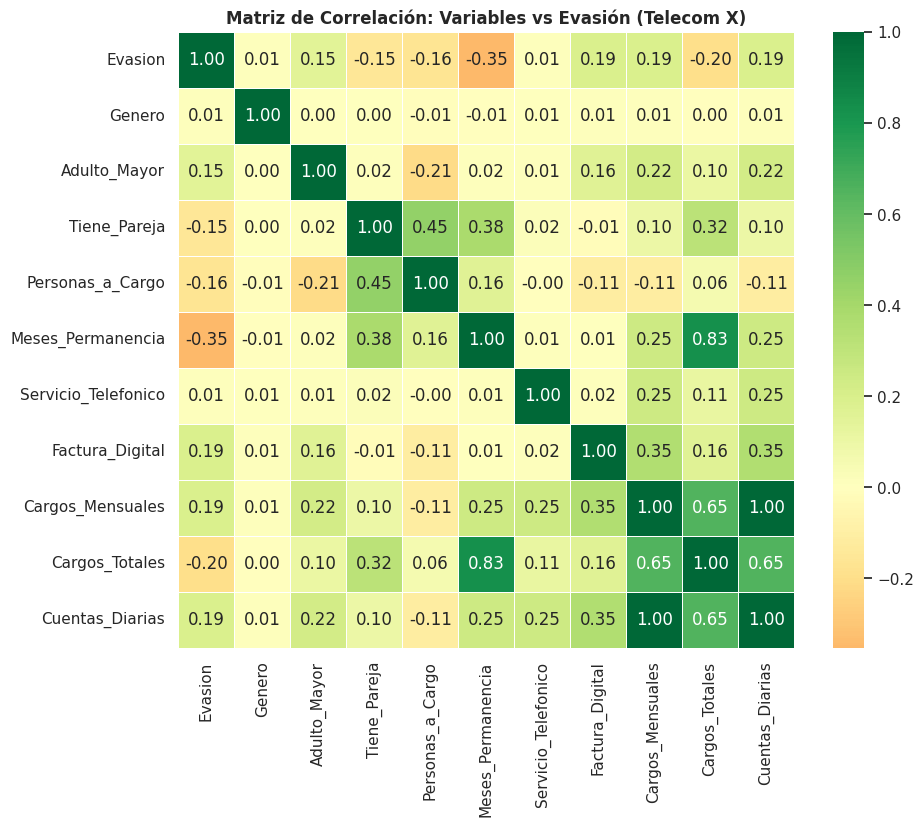

FACTORES CON MAYOR RELACIÓN DIRECTA CON LA EVASIÓN
Evasion                1.000000
Cargos_Mensuales       0.193356
Cuentas_Diarias        0.193356
Factura_Digital        0.191825
Adulto_Mayor           0.150889
Servicio_Telefonico    0.011942
Genero                 0.008612
Tiene_Pareja          -0.150448
Personas_a_Cargo      -0.164221
Cargos_Totales        -0.198324
Meses_Permanencia     -0.352229
Name: Evasion, dtype: float64

💡 NOTA: Los valores cercanos a 1 indican que la variable sube junto con la evasión.
💡 NOTA: Los valores negativos indican que la variable ayuda a retener al cliente.


In [119]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- ANÁLISIS DE CORRELACIÓN (SOLUCIÓN INTEGRADA) ---

# 1. Filtramos solo las columnas que son números para evitar el ValueError
# Esto permite que corr() funcione correctamente con tus variables estandarizadas
df_numerico = df_final.select_dtypes(include=['number'])

# 2. Calculamos la matriz de correlación de Pearson
matriz_corr = df_numerico.corr()

# 3. Configuración visual del Heatmap (Mapa de Calor)
plt.figure(figsize=(10, 8))
# Usamos un mapa de colores de Rojo (negativo) a Verde (positivo)
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='RdYlGn', center=0, square=True, linewidths=.5)

plt.title('Matriz de Correlación: Variables vs Evasión (Telecom X)', fontsize=12, fontweight='bold')
plt.show()

# 4. Extracción de Insights para el Informe Final
print('='*60)
print('FACTORES CON MAYOR RELACIÓN DIRECTA CON LA EVASIÓN')
print('='*60)
# Mostramos la relación de todas las variables con 'Evasion' de mayor a menor
ranking_evasion = matriz_corr['Evasion'].sort_values(ascending=False)
print(ranking_evasion)

print("\n💡 NOTA: Los valores cercanos a 1 indican que la variable sube junto con la evasión.")
print("💡 NOTA: Los valores negativos indican que la variable ayuda a retener al cliente.")

La matriz de correlación confirma estadísticamente las tendencias que se observo en los gráficos anteriores.

Antigüedad como Factor de Retención (Correlación Negativa: -0.35): La variable Meses_Permanencia tiene la relación más fuerte con la evasión, pero de forma inversa. Esto significa que a medida que aumenta la antigüedad del cliente, la probabilidad de que se vaya disminuye significativamente.

Impacto del Costo (Correlación Positiva: 0.19): Tanto Cargos_Mensuales como tu variable Cuentas_Diarias presentan una correlación positiva idéntica. Esto valida matemáticamente que los costos elevados están directamente asociados con un mayor riesgo de fuga.

Factores Demográficos y Digitales: Adulto_Mayor (0.15): Existe una correlación positiva moderada, lo que indica que este segmento es un poco más propenso a la evasión que el resto de la base.

Factura_Digital (0.19): Sorprendentemente, los clientes con factura digital muestran una correlación positiva con la evasión similar a la del costo mensual.

Factores de Lealtad: Tener Pareja (-0.15) o Personas_a_Cargo (-0.16) muestra correlaciones negativas. Los clientes con vínculos familiares tienden a ser más estables y presentan menor evasión.

###Conclusion del Informe

El análisis estadístico identifica a la antigüedad como el principal protector contra la fuga, mientras que el costo mensual/diario y la facturación digital son los principales indicadores que preceden la pérdida de un cliente".